In [1]:
import pickle

In [2]:
import pandas as pd 
card_scrna = pd.read_csv("../data/scrnaseq_raw.csv")

card_meta = pd.read_csv("../data/scrnaseq_metadata.csv")

In [3]:
import scanpy as sc 
adata_sc = sc.read("../data/scrnaseq_raw.h5ad")


In [4]:
adata_sc

AnnData object with n_obs × n_vars = 20155 × 499
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'sampleid', 'subclass_label', 'majorclass', 'author_cell_type', 'age', 'gender', 'reference', 'accession', 'sample_note', 'development_stage_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'library_platform', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'fea

In [4]:
savesimdir = '../results/simulations/pickles/'

In [5]:

N_range = [50] # [1,2] # [5, 10, 20, 50,  75, 100, 150,  250,  400, 500] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
linear_slope_variance_range = [0.1] #[0.0, 0.4, 0.8, 1.0]
linear_intercept_variance_range = [0.1] # [0.0, 0.4, 0.8, 1.0]
numcells_to_swap_range = [2] # [1, 2, 16, 50] # , 16] #[0, 2, 8, 16, 64, 250]
nneigh_range = [10]
nbd_swaps_range = [5]
   


In [6]:

import scanpy as sc 

import anndata

In [ ]:

spa_celltype_key='Types'


scrna_cluster_key = "majorclass"


adata_sc = sc.read("../data/scrnaseq_raw.h5ad")

common_celltypes = ['AC', 'BC', 'Cone', 'HC', 'MG', 'RGC', 'Rod'] # list(set(adata_sc.obs[scrna_cluster_key])) # define this according to dataset


# chose this since it seemed most similar in distribution to spatial samples
adata_sc = adata_sc[adata_sc.obs['reference'] == 'GSE243413 (2023) WT_CD73'].copy() 

In [8]:
adata_sc

AnnData object with n_obs × n_vars = 20155 × 499
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'sampleid', 'subclass_label', 'majorclass', 'author_cell_type', 'age', 'gender', 'reference', 'accession', 'sample_note', 'development_stage_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'library_platform', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'fea

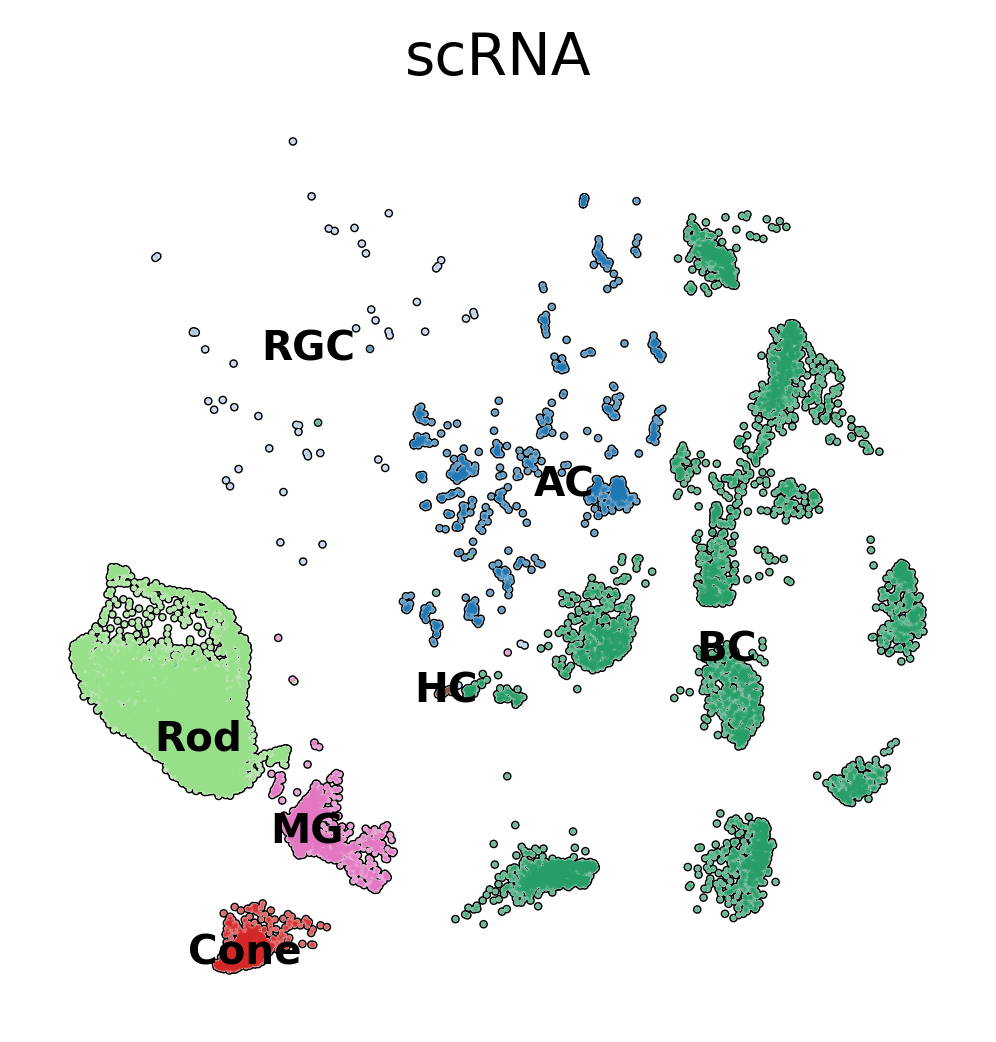

In [10]:
from matplotlib import colors
import matplotlib.pyplot as plt
# color_map
# sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3
from matplotlib_inline.backend_inline import set_matplotlib_formats
import IPython
IPython.display.set_matplotlib_formats = set_matplotlib_formats

sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42





sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,color='majorclass',title='scRNA',legend_loc='on data',save='_scRNAcelltypes.png')

# sc.pl.umap(adata_sc,color='majorclass', add_outline=True, frameon=False,legend_loc='on data',title='scRNA CellTypes',save='_scRNAcelltypes.png')

In [ ]:
# perform QC for reference based on 1st spatial sample 


save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N_range[0]) + '_linear_slope_var_' + str(linear_slope_variance_range[0]) + '_linear_int_var_' + str(linear_intercept_variance_range[0]) + '_' + str(numcells_to_swap_range[0]) + '.pickle'

with open(save_sim_file, 'rb') as handle:
    tmpa = pickle.load(handle)  
entry0 = list(tmpa.keys())[0]
entry1 = list(tmpa[entry0].keys())[0]
entry2 = list(tmpa[entry0][entry1].keys())[0]

genes_to_use = list((set(tmpa[entry0][entry1][entry2].var.index).intersection(set(adata_sc.var.index))))
print(len(genes_to_use))
genes_to_use.sort()

print(adata_sc.to_df().sum(axis=1).median())

adata_sc =  anndata.AnnData(X=adata_sc.to_df()[genes_to_use],obs=adata_sc.obs,uns=adata_sc.uns,obsm=adata_sc.obsm)
sc.pp.filter_cells(adata_sc,min_counts=1)

print(adata_sc.to_df().sum(axis=1).median())

sc.pp.normalize_total(adata_sc, target_sum=1000)

# print(adata_sc.to_df().sum(axis=1).median())

# sc.pp.log1p(adata_sc)

print(adata_sc.to_df().sum(axis=1).median())

adata_sc = adata_sc[adata_sc.obs[scrna_cluster_key].isin(common_celltypes)]

# highly variable gene selection 



if adata_sc.shape[1] > 1500:
    
    sc.tl.rank_genes_groups(adata_sc, groupby=scrna_cluster_key, method="wilcoxon")
    sc.tl.filter_rank_genes_groups(adata_sc,   key_added='rank_genes_groups_filtered',  min_fold_change=1.5)
    all_genes = sc.get.rank_genes_groups_df(adata_sc,group=None, key='rank_genes_groups_filtered', pval_cutoff=0.05, log2fc_min=1.5)
    all_genes = all_genes[~all_genes['names'].isna()]
    adata_sc = adata_sc[:,list(set(all_genes['names']))]
    disp_columns = []
    for ct in set(adata_sc.obs[scrna_cluster_key].values):
        adata_sc.var[ct + '_disperson'] = 0.0
        disp_columns.append(ct + '_disperson')
        tmpa = adata_sc[adata_sc.obs[scrna_cluster_key]==ct].copy()

        tmpb = tmpa.to_df().var() / (tmpa.to_df().mean() + 0.000001)

        adata_sc.var[ct + '_disperson'] = tmpb


    adata_sc.var['avg_dispersion'] = adata_sc.var[disp_columns].mean(axis=1)
    import numpy as np
    top_pct = np.quantile(a=adata_sc.var['avg_dispersion'], q=0.99)

    adata_sc = adata_sc[:,adata_sc.var['avg_dispersion'] < top_pct]
    

adata_sc.write_h5ad("../data/scrna_ref_norm1knolog.h5ad")




499
488.0
488.0
1000.0


In [ ]:

#cnt = 0

# N_range = [5, 10, 50,  100,  200] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
# nswaps_nbd_range = [2, 5, 10, 20, 50, 100]
# nneigh_range = [10]


N_range = [25,  75,  125, 150, 175] # [5, 10, 50,  100,  200] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
nswaps_nbd_range = [2]#, 5, 10, 20, 50, 100]
nneigh_range = [10]

for N in N_range:
        # for linear_slope_variance in linear_slope_variance_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        #     for linear_intercept_variance in linear_intercept_variance_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        for nneigh in nneigh_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            for nbdswaps in nswaps_nbd_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
                # for numcells_to_swap in numcells_to_swap_range:#[0, 2, 4, 8, 16, 32, 64, 128, 256]:
                    # save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '.pickle'
                    # write_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '_normnolog_nov2024_1k.pickle'
                    save_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '.pickle'
                    write_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_norm1knolog.pickle'
                    
                    with open(save_sim_file, 'rb') as handle:
                        adata_spot_swap = pickle.load(handle)

                    for entry0 in adata_spot_swap.keys():
                        for entry1 in adata_spot_swap[entry0].keys(): 
                            for entry2 in adata_spot_swap[entry0][entry1].keys():
                                #adata_st = adata_spot_swap[entry0][entry1][entry2].copy()
                                



                                genes_to_use = list((set(adata_sc.var.index).intersection(set(adata_spot_swap[entry0][entry1][entry2].var.index))))
                                # print(len(genes_to_use))
                                genes_to_use.sort()

                                # # adata_st = adata_st.copy()
                                adata_st =  anndata.AnnData(X=adata_spot_swap[entry0][entry1][entry2].to_df()[genes_to_use],obs=adata_spot_swap[entry0][entry1][entry2].obs,uns=adata_spot_swap[entry0][entry1][entry2].uns,obsm=adata_spot_swap[entry0][entry1][entry2].obsm)

                                

                                print(adata_st.to_df().sum(axis=1).median())
                                
                                

                                sc.pp.normalize_total(adata_st, target_sum=1000)

                                print(adata_st.to_df().sum(axis=1).median())
                                
                                

                                # common_celltypes = set(common_celltypes).union(set(adata_st.obs['spa_celltype_key']))
                                adata_spot_swap[entry0][entry1][entry2] = adata_st.copy()

                    with open(write_sim_file, 'wb') as handle:
                        pickle.dump(adata_spot_swap, handle, protocol=pickle.HIGHEST_PROTOCOL)
        


7621.0
1000.0
4279.0
1000.0
4290.0
1000.0
7011.5
1000.0
4162.0
1000.0
7767.0
1000.0
8126.0
1000.0
3436.0
1000.0
4732.0
1000.0
2189.0
1000.0
6387.0
1000.0
4423.0
1000.0
3415.5
1000.0
4662.0
1000.0
3727.0
1000.0
3003.0
1000.0
2219.0
1000.0
2994.0
1000.0
4138.0
1000.0
7111.5
1000.0
2367.0
1000.0
1569.0
1000.0
1427.5
1000.0
1554.0
1000.0
3036.0
1000.0
2444.0
1000.0
2764.5
1000.0
3099.0
1000.0
779.5
1000.0
1273.0
1000.0
2101.0
1000.0
2458.0
1000.0
409.0
1000.0
1182.0
1000.0
118.0
1000.0
565.0
1000.0
878.0
1000.0
342.0
1000.0
1199.0
1000.0
1124.0
1000.0
3397.0
1000.0
379.0
1000.0
3060.0
1000.0
7621.0
999.9999999999999
4279.0
1000.0
4290.0
999.9999999999999
6852.5
1000.0
4162.0
1000.0
7740.0
999.9999999999999
8126.0
999.9999999999999
3352.0
1000.0
4814.0
1000.0000000000002
2189.0
1000.0
6387.0
1000.0
4423.0
1000.0
3415.5
1000.0000000000001
4874.0
1000.0000000000005
3735.5
1000.0
3003.0
999.9999999999999
2230.0
1000.0
2994.0
1000.0000000000005
4160.0
1000.0
7066.0
1000.0000000000005
2367.0
999

## get raw for CARD, cell2location

- read raw 
- read normalized
- subset raw to normalized 
- save scRNAseq raw, as well as raw csvs 

In [15]:
import scanpy as sc

adata_sc_raw  = sc.read("../data/scrnaseq_raw.h5ad")

adata_sc = sc.read( "../data/scrna_ref_norm1knolog.h5ad")

adata_sc_raw = adata_sc_raw[adata_sc.obs.index,adata_sc.var.index]


adata_sc_raw.to_df().to_csv("../data/scrnaseq_raw.csv")

adata_sc_raw.obs.to_csv("../data/scrnaseq_metadata.csv")

adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [ ]:
adata_sc_raw = adata_sc_raw.copy()

for entry in ['citation', 'default_embedding', 'schema_reference', 'schema_version', 'title']: # cell2loc crashes with some entries due to version inconsistency
    del adata_sc_raw.uns[entry]

adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [20]:
adata_sc_raw

AnnData object with n_obs × n_vars = 20155 × 499
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'sampleid', 'subclass_label', 'majorclass', 'author_cell_type', 'age', 'gender', 'reference', 'accession', 'sample_note', 'development_stage_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'library_platform', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'fea